# Hands-on Activity 9.1 | Saving & Loading Models


# Procedure

## Save Your Models For Later With Serialization
Given that deep learning models can take hours, days and even weeks to train, it is important to know how to save and load them from disk. In this lesson, you will discover how you can save your Keras models to file and load them up again to make predictions. After completing this lesson, you will know:
- How to save and load Keras model weights to HDF5 formatted files.
- How to save and load Keras model structure to JSON files.
- How to save and load Keras model structure to YAML files.

Keras separates the concerns of saving your model architecture and saving your model weights.
Model weights are saved to `HDF5` format. This is a grid format that is ideal for storing
multi-dimensional arrays of numbers.

The model structure can be described and saved (and
loaded) using two different formats: `JSON` and `YAML`.
Each example will also demonstrate saving and loading your model weights to `HDF5` formatted files.

The examples will use the same simple network trained on the `Pima Indians onset of diabetes binary classification dataset`.

## HDF5 Format
The Hierarchical Data Format or `HDF`5 for short is a flexible data storage format and is
convenient for storing large arrays of real values, as we have in the weights of neural networks.

You may need to install Python support for the HDF5 file format. You can do this using your
preferred Python package management system such as Pip:

`pip install h5py`



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install h5py

## Save Your Neural Network Model to JSON
`JSON` is a simple file format for describing data hierarchically. Keras provides the ability to
describe any model using `JSON` format with a to `json()` function.

This can be saved to file
and later loaded via the model from `json()` function that will create a new model from the
`JSON` specification.

The weights are saved directly from the model using the save `weights()` function and
later loaded using the symmetrical `load_weights()` function.

The example below trains and
evaluates a simple model on the Pima Indians dataset. The model structure is then converted
to JSON format and written to `model.json` in the local directory.

The network weights are
written to `model.h5` in the local directory.

The model and weight data is loaded from the saved files and a new model is created. It is important to compile the loaded model before it is used. This is so that predictions made using the model can use the appropriate efficient computation from the Keras backend. The model is
evaluated in the same way printing the same evaluation score.

In [ ]:
# MLP for Pima Indians Dataset Serialize to JSON and HDF5
from tensorflow.keras.models import Sequential, model_from_json
from tensorflow.keras.layers import Dense
import numpy
import os

# fix random seed for reproducibility
numpy.random.seed(7)
# load pima indians dataset
# https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
dataset = numpy.loadtxt("/content/drive/MyDrive/CPE313/hoa9.1/diabetes.csv", delimiter=",", skiprows=1)

# split into input (X) and output (Y) variables
X = dataset[:,0:8]
Y = dataset[:,8]

# create model
model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Fit the model
model.fit(X, Y, epochs=150, batch_size=10, verbose=0)
# evaluate the model
scores = model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

# serialize model to JSON
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)
# serialize weights to HDF5
model.save_weights("/content/drive/MyDrive/CPE313/hoa9.1/saved models/model.weights.h5")
print("Saved model to disk")

# later...

# load json and create model
json_file = open('model.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)
# load weights into new model
loaded_model.load_weights("/content/drive/MyDrive/CPE313/hoa9.1/saved models/model.weights.h5")
print("Loaded model from disk")

# evaluate loaded model on test data
loaded_model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])
score = loaded_model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (loaded_model.metrics_names[1], score[1]*100))

compile_metrics: 69.92%
Saved model to disk
Loaded model from disk
compile_metrics: 69.92%


Running this example provides the output below. It shows first the accuracy of the trained
model, the saving of the model to disk in `JSON` format, the loading of the model and finally the
re-evaluation of the loaded model achieving the same accuracy.

The JSON format of the model looks like the following:
```
{  
   "class_name":"Sequential",
   "config":{  
      "name":"sequential_1",
      "layers":[  
         {  
            "class_name":"Dense",
            "config":{  
               "name":"dense_1",
               "trainable":true,
               "batch_input_shape":[  
                  null,
                  8
               ],
               "dtype":"float32",
               "units":12,
               "activation":"relu",
               "use_bias":true,
               "kernel_initializer":{  
                  "class_name":"VarianceScaling",
                  "config":{  
                     "scale":1.0,
                     "mode":"fan_avg",
                     "distribution":"uniform",
                     "seed":null
                  }
               },
               "bias_initializer":{  
                  "class_name":"Zeros",
                  "config":{  

                  }
               },
               "kernel_regularizer":null,
               "bias_regularizer":null,
               "activity_regularizer":null,
               "kernel_constraint":null,
               "bias_constraint":null
            }
         },
         {  
            "class_name":"Dense",
            "config":{  
               "name":"dense_2",
               "trainable":true,
               "dtype":"float32",
               "units":8,
               "activation":"relu",
               "use_bias":true,
               "kernel_initializer":{  
                  "class_name":"VarianceScaling",
                  "config":{  
                     "scale":1.0,
                     "mode":"fan_avg",
                     "distribution":"uniform",
                     "seed":null
                  }
               },
               "bias_initializer":{  
                  "class_name":"Zeros",
                  "config":{  

                  }
               },
               "kernel_regularizer":null,
               "bias_regularizer":null,
               "activity_regularizer":null,
               "kernel_constraint":null,
               "bias_constraint":null
            }
         },
         {  
            "class_name":"Dense",
            "config":{  
               "name":"dense_3",
               "trainable":true,
               "dtype":"float32",
               "units":1,
               "activation":"sigmoid",
               "use_bias":true,
               "kernel_initializer":{  
                  "class_name":"VarianceScaling",
                  "config":{  
                     "scale":1.0,
                     "mode":"fan_avg",
                     "distribution":"uniform",
                     "seed":null
                  }
               },
               "bias_initializer":{  
                  "class_name":"Zeros",
                  "config":{  

                  }
               },
               "kernel_regularizer":null,
               "bias_regularizer":null,
               "activity_regularizer":null,
               "kernel_constraint":null,
               "bias_constraint":null
            }
         }
      ]
   },
   "keras_version":"2.2.5",
   "backend":"tensorflow"
}
```

## Save Your Neural Network Model to YAML
This example is much the same as the above `JSON` example, except the `YAML` format is used
for the model specification.

The model is described using YAML, saved to file model.yaml and later loaded into a new model via the model from `yaml()` function. Weights are handled in the
same way as above in `HDF5` format as `model.h5`.




In [ ]:
# MLP for Pima Indians Dataset serialize to YAML and HDF5
from tensorflow.keras.models import Sequential, model_from_yaml
from tensorflow.keras.layers import Dense
import numpy
import os
# fix random seed for reproducibility
seed = 7
numpy.random.seed(seed)
# load pima indians dataset
dataset = numpy.loadtxt("/content/drive/MyDrive/CPE313/hoa9.1/diabetes.csv", delimiter=",", skiprows=1)
# split into input (X) and output (Y) variables
X = dataset[:,0:8]
Y = dataset[:,8]
# create model
model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Fit the model
model.fit(X, Y, epochs=150, batch_size=10, verbose=0)
# evaluate the model
scores = model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

# serialize model to YAML
model_yaml = model.to_json()
with open("model.yaml", "w") as yaml_file:
    yaml_file.write(model_yaml)
# serialize weights to HDF5
model.save_weights("/content/drive/MyDrive/CPE313/hoa9.1/saved models/model_yaml.h5")
print("Saved model to disk")

# later...

# load YAML and create model
yaml_file = open('model.yaml', 'r')
loaded_model_yaml = yaml_file.read()
yaml_file.close()
loaded_model = model_from_json(loaded_model_yaml)
# load weights into new model
loaded_model.load_weights("/content/drive/MyDrive/CPE313/hoa9.1/saved models/model_yaml.h5")
print("Loaded model from disk")

# evaluate loaded model on test data
loaded_model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])
score = loaded_model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (loaded_model.metrics_names[1], score[1]*100))

ImportError: cannot import name 'model_from_yaml' from 'tensorflow.keras.models' (/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/models/__init__.py)

**Note: model.to_yaml() was deprecated in TensorFlow 2.6 and fully removed in TF 2.9+. Running it on any modern TF version will throw an AttributeError**

Running the example displays the output below. Again, the example demonstrates the accuracy of the model, the model serialization, deserialization and re-evaluation achieving the same results.

The model described in YAML format looks like the following:

```
backend: tensorflow
class_name: Sequential
config:
  layers:
  - class_name: Dense
    config:
      activation: relu
      activity_regularizer: null
      batch_input_shape: !!python/tuple
      - null
      - 8
      bias_constraint: null
      bias_initializer:
        class_name: Zeros
        config: {}
      bias_regularizer: null
      dtype: float32
      kernel_constraint: null
      kernel_initializer:
        class_name: VarianceScaling
        config:
          distribution: uniform
          mode: fan_avg
          scale: 1.0
          seed: null
      kernel_regularizer: null
      name: dense_1
      trainable: true
      units: 12
      use_bias: true
  - class_name: Dense
    config:
      activation: relu
      activity_regularizer: null
      bias_constraint: null
      bias_initializer:
        class_name: Zeros
        config: {}
      bias_regularizer: null
      dtype: float32
      kernel_constraint: null
      kernel_initializer:
        class_name: VarianceScaling
        config:
          distribution: uniform
          mode: fan_avg
          scale: 1.0
          seed: null
      kernel_regularizer: null
      name: dense_2
      trainable: true
      units: 8
      use_bias: true
  - class_name: Dense
    config:
      activation: sigmoid
      activity_regularizer: null
      bias_constraint: null
      bias_initializer:
        class_name: Zeros
        config: {}
      bias_regularizer: null
      dtype: float32
      kernel_constraint: null
      kernel_initializer:
        class_name: VarianceScaling
        config:
          distribution: uniform
          mode: fan_avg
          scale: 1.0
          seed: null
      kernel_regularizer: null
      name: dense_3
      trainable: true
      units: 1
      use_bias: true
  name: sequential_1
keras_version: 2.2.5
```


## How to Save a Keras Model
You can save your model by calling the `save()` function on the model and specifying the filename.

The example below demonstrates this by first fitting a model, evaluating it, and saving it to the file model.h5.

In [ ]:
# MLP for Pima Indians Dataset saved to single file
from numpy import loadtxt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# load pima indians dataset
dataset = numpy.loadtxt("/content/drive/MyDrive/CPE313/hoa9.1/diabetes.csv", delimiter=",", skiprows=1)
# split into input (X) and output (Y) variables
X = dataset[:,0:8]
Y = dataset[:,8]
# define model
model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Fit the model
model.fit(X, Y, epochs=150, batch_size=10, verbose=0)
# evaluate the model
scores = model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))
# save model and architecture to single file
model.save("model.h5")
print("Saved model to disk")

compile_metrics: 77.08%
Saved model to disk


## Keep The Best Models During Training With Checkpointing

Deep learning models can take hours, days or even weeks to train and if a training run is stopped
unexpectedly, you can lose a lot of work. In this lesson, you will discover how you can **checkpoint
your deep learning models** during training in Python using the Keras library. After completing
this lesson you will know:
- The importance of checkpointing neural network models when training.
- How to checkpoint each improvement to a model during training.
- How to checkpoint the very best model observed during training.

---

## Checkpointing Neural Network Models

**Application checkpointing** is a *fault tolerance technique for long running processes*.

It is an approach where a snapshot of the state of the system is taken in case of system failure.

If there is a problem, not all is lost. The checkpoint may be used directly, or used as the starting point for a new run, picking up where it left off.

When training deep learning models, the checkpoint captures the weights of the model. These weights can be used to make predictions as-is, or used as the basis for ongoing training.

The **Keras library** provides a checkpointing capability by a callback API. The `ModelCheckpoint`
callback class allows you to define where to checkpoint the model weights, how the file should
be named and under what circumstances to make a checkpoint of the model.

The API allows you to specify which metric to monitor, such as loss or accuracy on the training or validation dataset.

You can specify whether to look for an improvement in maximizing or minimizing the score.

Finally, the filename that you use to store the weights can include variables like the epoch number or metric.

The `ModelCheckpoint` instance can then be passed to the training
process when calling the `fit()` function on the model. Note, you may need to install the `h5py` library.

# Checkpoint Neural Network Model Improvements

A good use of checkpointing is to output the model weights each time an improvement is observed during training.

The example below creates a small neural network for the `Pima
Indians onset of diabetes binary classification problem.`

The example uses `33%` of the data for validation.

Checkpointing is setup to save the network weights only when there is an improvement in classification accuracy on the validation dataset `(monitor=’val acc’ and mode=’max’)`. The weights are stored in a file that includes the score in the filename `weights-improvement-val acc=.2f.hdf5`.



In [ ]:
# Checkpoint the weights when validation accuracy improves
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
seed = 42
tf.random.set_seed(seed)
# load pima indians dataset
dataset = numpy.loadtxt("/content/drive/MyDrive/CPE313/hoa9.1/diabetes.csv", delimiter=",", skiprows=1)
# split into input (X) and output (Y) variables
X = dataset[:,0:8]
Y = dataset[:,8]
# create model
model = Sequential()
model.add(Dense(12, input_shape=(8,), activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# checkpoint
filepath = "weights-improvement-{epoch:02d}-{val_accuracy:.2f}.keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list = [checkpoint]

# Fit the model
model.fit(X, Y, validation_split=0.33, epochs=150, batch_size=10, callbacks=callbacks_list, verbose=0)


Epoch 1: val_accuracy improved from None to 0.68898, saving model to weights-improvement-01-0.69.keras

Epoch 1: finished saving model to weights-improvement-01-0.69.keras

Epoch 2: val_accuracy did not improve from 0.68898

Epoch 3: val_accuracy did not improve from 0.68898

Epoch 4: val_accuracy improved from 0.68898 to 0.69291, saving model to weights-improvement-04-0.69.keras

Epoch 4: finished saving model to weights-improvement-04-0.69.keras

Epoch 5: val_accuracy did not improve from 0.69291

Epoch 6: val_accuracy improved from 0.69291 to 0.69685, saving model to weights-improvement-06-0.70.keras

Epoch 6: finished saving model to weights-improvement-06-0.70.keras

Epoch 7: val_accuracy did not improve from 0.69685

Epoch 8: val_accuracy did not improve from 0.69685

Epoch 9: val_accuracy did not improve from 0.69685

Epoch 10: val_accuracy did not improve from 0.69685

Epoch 11: val_accuracy did not improve from 0.69685

Epoch 12: val_accuracy did not improve from 0.69685

Epo

You will also see a number of files in your working directory containing the network weights
in HDF5 format. For example:
```
...
weights-improvement-74-0.81.hdf5
weights-improvement-81-0.82.hdf5
weights-improvement-91-0.82.hdf5
weights-improvement-93-0.83.hdf5
```

This is a very simple checkpointing strategy. It may create a lot of unnecessary checkpoint
files if the validation accuracy moves up and down over training epochs. Nevertheless, it will ensure that you have a snapshot of the best model discovered during your run.

## Checkpoint Best Neural Network Model Only

A simpler checkpoint strategy is to save the model weights to the same file, if and only if the validation accuracy improves. This can be done easily using the same code from above and
changing the output filename to be fixed (not include score or epoch information). In this case, model weights are written to the file `weights.best.hdf5` only if the classification accuracy of the model on the validation dataset improves over the best seen so far.



In [ ]:
# Checkpoint the weights for best model on validation accuracy
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

# load pima indians dataset
dataset = np.loadtxt("/content/drive/MyDrive/CPE313/hoa9.1/diabetes.csv", delimiter=",", skiprows=1)

# split into input (X) and output (Y) variables
X = dataset[:,0:8]
Y = dataset[:,8]

# create model
model = Sequential()
model.add(Dense(12, input_shape=(8,), activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# checkpoint — saves only the best model based on val_accuracy
filepath = "weights.best.keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list = [checkpoint]

# Fit the model
model.fit(X, Y, validation_split=0.33, epochs=150, batch_size=10, callbacks=callbacks_list, verbose=0)


Epoch 1: val_accuracy improved from None to 0.32677, saving model to weights.best.keras

Epoch 1: finished saving model to weights.best.keras

Epoch 2: val_accuracy improved from 0.32677 to 0.46457, saving model to weights.best.keras

Epoch 2: finished saving model to weights.best.keras

Epoch 3: val_accuracy improved from 0.46457 to 0.55118, saving model to weights.best.keras

Epoch 3: finished saving model to weights.best.keras

Epoch 4: val_accuracy improved from 0.55118 to 0.59055, saving model to weights.best.keras

Epoch 4: finished saving model to weights.best.keras

Epoch 5: val_accuracy improved from 0.59055 to 0.60630, saving model to weights.best.keras

Epoch 5: finished saving model to weights.best.keras

Epoch 6: val_accuracy improved from 0.60630 to 0.64567, saving model to weights.best.keras

Epoch 6: finished saving model to weights.best.keras

Epoch 7: val_accuracy improved from 0.64567 to 0.65748, saving model to weights.best.keras

Epoch 7: finished saving model to 

Running this example provides the following output (truncated for brevity):
```
...
Epoch 00136: val_acc did not improve
Epoch 00137: val_acc did not improve
Epoch 00138: val_acc did not improve
Epoch 00139: val_acc did not improve
Epoch 00140: val_acc improved from 0.83465 to 0.83858, saving model to weights.best.hdf5
Epoch 00141: val_acc did not improve
Epoch 00142: val_acc did not improve
Epoch 00143: val_acc did not improve
Epoch 00144: val_acc did not improve
Epoch 00145: val_acc did not improve
Epoch 00146: val_acc improved from 0.83858 to 0.84252, saving model to weights.best.hdf5
Epoch 00147: val_acc did not improve
Epoch 00148: val_acc improved from 0.84252 to 0.84252, saving model to weights.best.hdf5
Epoch 00149: val_acc did not improve
```
You should see the weight file in your local directory.

`weights.best.hdf5`

## Loading a Saved Neural Network Model

Now that you have seen how to checkpoint your deep learning models during training, you need
to review how to load and use a `checkpointed model`.

The checkpoint only includes the model weights. It assumes you know the network structure. This too can be serialize to file in `JSON`
or `YAML` format.

In the example below, the model structure is known and the best weights are loaded from the previous experiment, stored in the working directory in the `weights.best.hdf5`
file. The model is then used to make predictions on the entire dataset.

In [ ]:
# How to load and use weights from a checkpoint
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import ModelCheckpoint
import numpy as np

# fix random seed for reproducibility
seed = 7
np.random.seed(seed)

# create model
model = Sequential()
model.add(Dense(12, input_dim=8, kernel_initializer='uniform', activation='relu'))
model.add(Dense(8, kernel_initializer='uniform', activation='relu'))
model.add(Dense(1, kernel_initializer='uniform', activation='sigmoid'))

# Compile model first before loading weights
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# load pima indians dataset
dataset = np.loadtxt("/content/drive/MyDrive/CPE313/hoa9.1/diabetes.csv", delimiter=",", skiprows=1)

# split into input (X) and output (Y) variables
X = dataset[:,0:8]
Y = dataset[:,8]

# build the model graph by passing a batch of data through it
model.predict(X[:1])

# load weights
model.load_weights("weights.best.keras")
print("Created model and loaded weights from file")

# estimate accuracy on whole dataset using loaded weights
scores = model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
Created model and loaded weights from file


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


compile_metrics: 73.96%


## Summary
In this lesson you have discovered the importance of checkpointing deep learning models for long training runs. You learned:
- How to use Keras to checkpoint each time an improvement to the model is observed.
- How to only checkpoint the very best model observed during training.
- How to load a checkpointed model from file and use it later to make predictions.

---

## Understand Model Behavior During Training By Plotting History

You can learn a lot about neural networks and deep learning models by observing their performance over time during training.

In this lesson, you will discover how you can review and visualize the performance of deep learning models over time during training in Python with Keras. After completing this lesson you will know:

- How to inspect the history metrics collected during training.
- How to plot accuracy metrics on training and validation datasets during training.
- How to plot model loss metrics on training and validation datasets during training.

## Access Model Training History in Keras

Keras provides the capability to register callbacks when training a deep learning model. One of
the default callbacks that is registered when training all deep learning models is the History
callback. It records training metrics for each epoch. This includes the loss and the accuracy (for classification problems) as well as the loss and accuracy for the validation dataset, if one is set.

The history object is returned from calls to the `fit()` function used to train the model.

Metrics are stored in a dictionary in the history member of the object returned. For example, you can list the metrics collected in a history object using the following snippet of code after a model is trained:
```
# list all data in history
print(history.history.keys())
```

For example, for a model trained on a classification problem with a validation dataset, this
might produce the following listing:
```
[ acc , loss , val_acc , val_loss ]
```

We can use the data collected in the history object to create plots. The plots can provide an indication of useful things about the training of the model, such as:
- It’s speed of convergence over epochs (slope).
- Whether the model may have already converged (plateau of the line).
- Whether the model may be over-learning the training data (inflection for validation line).
- And more.

## Visualize Model Training History in Keras

We can create plots from the collected history data. In the example below we create a
small network to model the Pima Indians onset of diabetes binary classification problem.

The example collects the history, returned from training the model and creates two charts:
1. A plot of accuracy on the training and validation datasets over training epochs.
2. A plot of loss on the training and validation datasets over training epochs.



Epoch 1/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.4222 - loss: 3.7526 - val_accuracy: 0.4843 - val_loss: 2.3207
Epoch 2/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4591 - loss: 2.1658 - val_accuracy: 0.4843 - val_loss: 1.7919
Epoch 3/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4669 - loss: 1.6603 - val_accuracy: 0.4882 - val_loss: 1.3698
Epoch 4/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4630 - loss: 1.3041 - val_accuracy: 0.5197 - val_loss: 1.0711
Epoch 5/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5039 - loss: 1.0316 - val_accuracy: 0.6024 - val_loss: 0.9078
Epoch 6/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5778 - loss: 0.8681 - val_accuracy: 0.6378 - val_loss: 0.8118
Epoch 7/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5973 - loss: 0.7945 - val_accuracy: 0.6575 - val_loss: 0.7773
Epoch 8/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6187 - loss: 0.7569 - val_accuracy: 0.6693 - 

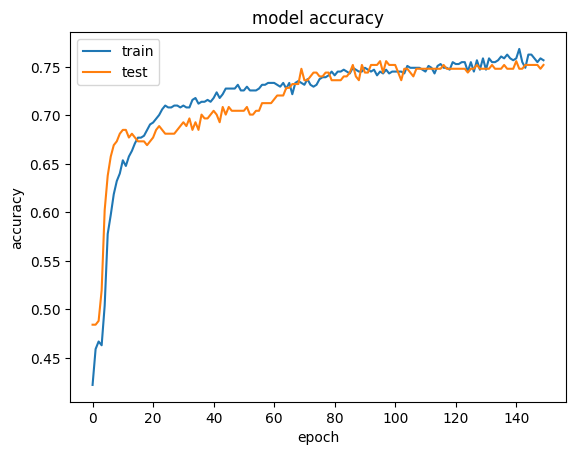

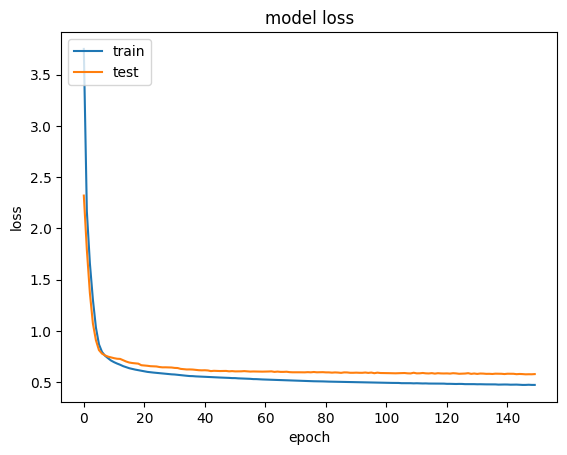

In [ ]:
# Visualize training history
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
import numpy as np
# load pima indians dataset
dataset = np.loadtxt("/content/drive/MyDrive/CPE313/hoa9.1/diabetes.csv", delimiter=",", skiprows=1)
# split into input (X) and output (Y) variables
X = dataset[:,0:8]
Y = dataset[:,8]
# create model
model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Fit the model
history = model.fit(X, Y, validation_split=0.33, epochs=150, batch_size=10, verbose=1)


# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

The history for the validation dataset is labeled test by convention as it is indeed a test dataset for the model.

From the plot of the accuracy, you can see that the model could probably be trained a little more as the trend for accuracy on both datasets is still rising for the last few epochs. You can also see that the model has not yet over-learned the training dataset, showing comparable skill on both datasets.

## Summary
In this lesson, you discovered the importance of collecting and reviewing metrics during the
training of your deep learning models. You learned:
- How to inspect a history object returned from training to discover the metrics that were
collected.
- How to extract model accuracy information for training and validation datasets and plot
the data.
- How to extract and plot the model loss information calculated from training and validation
datasets.



## Reduce Overfitting With Dropout Regularization

A simple and powerful regularization technique for neural networks and deep learning models is dropout. In this lesson, you will discover the dropout regularization technique and how to apply it to your models in Python with Keras.

After completing this lesson you will know:
- How the dropout regularization technique works.
- How to use dropout on your input and hidden layers.
- How to use dropout on your hidden layers.

## Dropout Regularization For Neural Networks

**Dropout** is a regularization technique for neural network models proposed by Srivastava, et al.
in their 2014 paper Dropout: A Simple Way to Prevent Neural Networks from Overfitting1.
Dropout is a technique where randomly selected neurons are ignored during training. They
are `dropped-out` randomly.

This means that their contribution to the activation of downstream
neurons is temporally removed on the forward pass and any weight updates are not applied to the neuron on the backward pass.

As a neural network learns, neuron weights settle into their context within the network.

Weights of neurons are tuned for specific features providing some specialization. Neighboring
neurons become to rely on this specialization, which if taken too far can result in a fragile model
too specialized to the training data. This reliant on context for a neuron during training is
referred to as *complex co-adaptations*.

You can imagine that if neurons are randomly dropped out of the network during training, that other neurons will have to step in and handle the
representation required to make predictions for the missing neurons.

This is believed to result
in multiple independent internal representations being learned by the network.

The effect is that the network becomes less sensitive to the specific weights of neurons. This
in turn results in a network that is capable of better generalization and is less likely to overfit the training data.

## Dropout Regularization in Keras

Dropout is easily implemented by randomly selecting nodes to be dropped-out with a given probability (e.g. 20%) each weight update cycle. This is how Dropout is implemented in Keras.

Dropout is only used during the training of a model and is not used when evaluating the skill of
the model. Next we will explore a few different ways of using Dropout in Keras.

The examples will use the Sonar dataset binary classification dataset. We will evaluate the developed models using scikit-learn with 10-fold cross validation,
in order to better tease out differences in the results.

There are 60 input values and a single output value and the input values are standardized before being used in the network. The
baseline neural network model has two hidden layers, the first with 60 units and the second with 30.

Stochastic gradient descent is used to train the model with a relatively low learning rate and momentum. The full baseline model is listed below.

In [2]:
!pip install -q "scikeras==0.13.0"

In [ ]:
!pip install -q --upgrade scikeras

In [5]:
# Baseline Model on the Sonar Dataset - manual CV (no scikeras)
from pandas import read_csv
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# load dataset
# https://www.kaggle.com/datasets/ypzhangsam/sonaralldata
dataframe = read_csv("/content/drive/MyDrive/CPE313/hoa9.1/sonar.all-data.csv", header=None)
dataset = dataframe.values

# split into input (X) and output (Y) variables
X = dataset[:,0:60].astype(float)
Y = dataset[:,60]

# encode class values as integers
encoder = LabelEncoder()
encoded_Y = encoder.fit_transform(Y)

# baseline model
def create_baseline():
    model = Sequential([
        Input(shape=(60,)),
        Dense(60, activation='relu'),
        Dense(30, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    sgd = SGD(learning_rate=0.01, momentum=0.8)
    model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy'])
    return model

# manual stratified k-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

for train_idx, test_idx in kfold.split(X, encoded_Y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = encoded_Y[train_idx], encoded_Y[test_idx]

    # scale inside each fold to prevent data leakage
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = create_baseline()
    model.fit(X_train, y_train, epochs=300, batch_size=16, verbose=0)

    _, acc = model.evaluate(X_test, y_test, verbose=0)
    results.append(acc)
    print(f"  Fold accuracy: {acc*100:.2f}%")

results = np.array(results)
print("\nBaseline: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

  Fold accuracy: 95.24%
  Fold accuracy: 71.43%
  Fold accuracy: 71.43%
  Fold accuracy: 95.24%
  Fold accuracy: 80.95%
  Fold accuracy: 85.71%
  Fold accuracy: 80.95%
  Fold accuracy: 90.48%
  Fold accuracy: 80.00%
  Fold accuracy: 90.00%

Baseline: 84.14% (8.27%)


## Using Dropout on the Visible Layer

Dropout can be applied to input neurons called the visible layer.

In the example below we add a new Dropout layer between the input (or visible layer) and the first hidden layer. The dropout
rate is set to 20%, meaning one in five inputs will be randomly excluded from each update cycle.

Additionally, as recommended in the original paper on dropout, a constraint is imposed on
the weights for each hidden layer, ensuring that the maximum norm of the weights does not
exceed a value of 3. This is done by setting the `W` constraint argument on the Dense class
when constructing the layers. The learning rate was lifted by one order of magnitude and the momentum was increased to 0.9. These increases in the learning rate were also recommended in the original dropout paper. Continuing on from the baseline example above, the code below exercises the same network with input dropout.

In [6]:
# Example of Dropout on the Sonar Dataset: Visible Layer
from pandas import read_csv
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.constraints import MaxNorm
from tensorflow.keras.optimizers import SGD
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# load dataset
dataframe = read_csv("/content/drive/MyDrive/CPE313/hoa9.1/sonar.all-data.csv", header=None)
dataset = dataframe.values

X = dataset[:,0:60].astype(float)
Y = dataset[:,60]

encoder = LabelEncoder()
encoded_Y = encoder.fit_transform(Y)

# dropout in the input layer with weight constraint
def create_model():
    model = Sequential([
        Input(shape=(60,)),
        Dropout(0.2),
        Dense(60, activation='relu', kernel_constraint=MaxNorm(3)),
        Dense(30, activation='relu', kernel_constraint=MaxNorm(3)),
        Dense(1, activation='sigmoid')
    ])
    sgd = SGD(learning_rate=0.1, momentum=0.9)
    model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy'])
    return model

# manual stratified k-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

for train_idx, test_idx in kfold.split(X, encoded_Y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = encoded_Y[train_idx], encoded_Y[test_idx]  # fixed typo

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = create_model()
    model.fit(X_train, y_train, epochs=300, batch_size=16, verbose=0)

    _, acc = model.evaluate(X_test, y_test, verbose=0)
    results.append(acc)
    print(f"  Fold accuracy: {acc*100:.2f}%")

results = np.array(results)
print("Visible: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

  Fold accuracy: 100.00%
  Fold accuracy: 76.19%
  Fold accuracy: 85.71%
  Fold accuracy: 90.48%
  Fold accuracy: 90.48%
  Fold accuracy: 100.00%
  Fold accuracy: 90.48%
  Fold accuracy: 95.24%
  Fold accuracy: 80.00%
  Fold accuracy: 90.00%
Visible: 89.86% (7.33%)


## Using Dropout on Hidden Layers
Dropout can be applied to hidden neurons in the body of your network model. In the example
below dropout is applied between the two hidden layers and between the last hidden layer and the output layer. Again a dropout rate of 20% is used as is a weight constraint on those layers.


In [7]:
# Example of Dropout on the Sonar Dataset: Hidden Layer
from pandas import read_csv
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.constraints import MaxNorm
from tensorflow.keras.optimizers import SGD
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# load dataset
dataframe = read_csv("/content/drive/MyDrive/CPE313/hoa9.1/sonar.all-data.csv", header=None)
dataset = dataframe.values

X = dataset[:,0:60].astype(float)
Y = dataset[:,60]

encoder = LabelEncoder()
encoded_Y = encoder.fit_transform(Y)

# dropout in hidden layers with weight constraint
def create_model():
    model = Sequential([
        Input(shape=(60,)),
        Dense(60, activation='relu', kernel_constraint=MaxNorm(3)),
        Dropout(0.2),
        Dense(30, activation='relu', kernel_constraint=MaxNorm(3)),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    sgd = SGD(learning_rate=0.1, momentum=0.9)
    model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy'])
    return model

# manual stratified k-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

for train_idx, test_idx in kfold.split(X, encoded_Y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = encoded_Y[train_idx], encoded_Y[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = create_model()
    model.fit(X_train, y_train, epochs=300, batch_size=16, verbose=0)

    _, acc = model.evaluate(X_test, y_test, verbose=0)
    results.append(acc)
    print(f"  Fold accuracy: {acc*100:.2f}%")

results = np.array(results)
print("Hidden: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

  Fold accuracy: 85.71%
  Fold accuracy: 76.19%
  Fold accuracy: 85.71%
  Fold accuracy: 90.48%
  Fold accuracy: 80.95%
  Fold accuracy: 95.24%
  Fold accuracy: 90.48%
  Fold accuracy: 80.95%
  Fold accuracy: 80.00%
  Fold accuracy: 90.00%
Hidden: 85.57% (5.68%)


We can see that for this problem and for the chosen network configuration that using dropout
in the hidden layers did not lift performance. In fact, performance was worse than the baseline.

It is possible that additional training epochs are required or that further tuning is required to the learning rate.

## Tips For Using Dropout
The original paper on Dropout provides experimental results on a suite of standard machine learning problems. As a result they provide a number of useful heuristics to consider when using dropout in practice:

- Generally use a small dropout value of 20%-50% of neurons with 20% providing a good
starting point. A probability too low has minimal effect and a value too high results in
under-learning by the network.
- Use a larger network. You are likely to get better performance when dropout is used
on a larger network, giving the model more of an opportunity to learn independent
representations.
- Use dropout on input (visible) as well as hidden layers. Application of dropout at each
layer of the network has shown good results.
Use a large learning rate with decay and a large momentum. Increase your learning rate
by a factor of 10 to 100 and use a high momentum value of 0.9 or 0.99.
- Constrain the size of network weights. A large learning rate can result in very large
network weights. Imposing a constraint on the size of network weights such as max-norm
regularization with a size of 4 or 5 has been shown to improve results.

## Summary
In this lesson, you discovered the dropout regularization technique for deep learning models. You learned:
- What dropout is and how it works.
- How you can use dropout on your own deep learning models.
- Tips for getting the best results from dropout on your own models.

## Lift Performance With Learning Rate Schedules
Training a neural network or large deep learning model is a difficult optimization task. The classical algorithm to train neural networks is called stochastic gradient descent. It has been well established that you can achieve increased performance and faster training on some problems by using a learning rate that changes during training. In this lesson you will discover how you can use different learning rate schedules for your neural network models in Python using the
Keras deep learning library. After completing this lesson you will know:

- The benefit of learning rate schedules on lifting model performance during training.
- How to configure and evaluate a time-based learning rate schedule.
- How to configure and evaluate a drop-based learning rate schedule.

## Learning Rate Schedule For Training Models

Adapting the learning rate for your stochastic gradient descent optimization procedure can
increase performance and reduce training time. Sometimes this is called learning rate annealing or adaptive learning rates. Here we will call this approach a learning rate schedule, were the default schedule is to use a constant learning rate to update network weights for each training epoch.

The simplest and perhaps most used adaptation of learning rates during training are
techniques that reduce the learning rate over time. These have the benefit of making large
changes at the beginning of the training procedure when larger learning rate values are used, and decreasing the learning rate such that a smaller rate and therefore smaller training updates are made to weights later in the training procedure. This has the effect of quickly learning good weights early and fine tuning them later. Two popular and easy to use learning rate schedules
are as follows:
- Decrease the learning rate gradually based on the epoch.
- Decrease the learning rate using punctuated large drops at specific epochs.

## Ionosphere Classification Dataset
The Ionosphere binary classification problem is used as a demonstration in this lesson. The
dataset describes radar returns where the target was free electrons in the ionosphere. It is a binary classification problem where positive cases (g for good) show evidence of some type of structure in the ionosphere and negative cases (b for bad) do not. It is a good dataset for practicing with neural networks because all of the inputs are small numerical values of the same
scale. There are 34 attributes and 351 observations.

State-of-the-art results on this dataset achieve an accuracy of approximately 94% to 98%
accuracy using 10-fold cross validation1.

The dataset is available here:
- http://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data

Alternatively, you can download it directly from the UCI Machine Learning
repository.
- https://archive.ics.uci.edu/ml/datasets/Ionosphere



## Time-Based Learning Rate Schedule
Keras has a time-based learning rate schedule built in. The stochastic gradient descent optimization algorithm implementation in the SGD class has an argument called decay. This argument is used in the time-based learning rate decay schedule equation as follows:
```
LearningRate = LearningRate * 1/(1 + decay * epoch)
```

When the decay argument is zero (the default), this has no effect on the learning rate (e.g.
0.1).
```
LearningRate = 0.1 * 1/(1 + 0.0 * 1)
LearningRate = 0.1
```

When the decay argument is specified, it will decrease the learning rate from the previous
epoch by the given fixed amount. For example, if we use the initial learning rate value of 0.1
and the decay of 0.001, the first 5 epochs will adapt the learning rate as follows:
```
Epoch Learning Rate
1 0.1
2 0.0999000999
3 0.0997006985
4 0.09940249103
5 0.09900646517
```

Extending this out to 100 epochs will produce the following graph of learning rate (y-axis) versus epoch (x-axis):

<img src='https://machinelearningmastery.com/wp-content/uploads/2016/05/Time-Based-Learning-Rate-Schedule.png'/>

You can create a nice default schedule by setting the decay value as follows:
```
Decay = LearningRate / Epochs
Decay = 0.1 / 100
Decay = 0.001
```

The example below demonstrates using the time-based learning rate adaptation schedule in
Keras. A small neural network model is constructed with a single hidden layer with 34 neurons and using the rectifier activation function. The output layer has a single neuron and uses the sigmoid activation function in order to output probability-like values. The learning rate for stochastic gradient descent has been set to a higher value of 0.1. The model is trained for 50 epochs and the decay argument has been set to 0.002, calculated as 0.1/50 .

Additionally, it can be a good idea to use momentum when using an adaptive learning rate. In this case we use a momentum value of 0.8. The complete example is listed below.



In [9]:
# Time Based Learning Rate Decay
from pandas import read_csv
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers.schedules import InverseTimeDecay
from sklearn.preprocessing import LabelEncoder

# load dataset
dataframe = read_csv("/content/drive/MyDrive/CPE313/hoa9.1/ionosphere.data", header=None)
dataset = dataframe.values

# split into input (X) and output (Y) variables
X = dataset[:,0:34].astype(float)
Y = dataset[:,34]

# encode class values as integers
encoder = LabelEncoder()
Y = encoder.fit_transform(Y)

# create model
model = Sequential([
    Input(shape=(34,)),
    Dense(34, activation='relu'),
    Dense(1, activation='sigmoid')
])

# time-based learning rate decay via InverseTimeDecay schedule
epochs = 50
learning_rate = 0.1
decay_rate = learning_rate / epochs
momentum = 0.8

lr_schedule = InverseTimeDecay(
    initial_learning_rate=learning_rate,
    decay_steps=1,
    decay_rate=decay_rate
)

sgd = SGD(learning_rate=lr_schedule, momentum=momentum, nesterov=False)
model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy'])

# Fit the model
model.fit(X, Y, validation_split=0.33, epochs=epochs, batch_size=28, verbose=2)

Epoch 1/50
9/9 - 3s - 355ms/step - accuracy: 0.7234 - loss: 0.5831 - val_accuracy: 0.8448 - val_loss: 0.4822
Epoch 2/50
9/9 - 0s - 12ms/step - accuracy: 0.8553 - loss: 0.4058 - val_accuracy: 0.9224 - val_loss: 0.2882
Epoch 3/50
9/9 - 0s - 12ms/step - accuracy: 0.9191 - loss: 0.2976 - val_accuracy: 0.9655 - val_loss: 0.2319
Epoch 4/50
9/9 - 0s - 12ms/step - accuracy: 0.9191 - loss: 0.2449 - val_accuracy: 0.9569 - val_loss: 0.2443
Epoch 5/50
9/9 - 0s - 14ms/step - accuracy: 0.9191 - loss: 0.2068 - val_accuracy: 0.9483 - val_loss: 0.2131
Epoch 6/50
9/9 - 0s - 12ms/step - accuracy: 0.9404 - loss: 0.1911 - val_accuracy: 0.9655 - val_loss: 0.1327
Epoch 7/50
9/9 - 0s - 12ms/step - accuracy: 0.9489 - loss: 0.1635 - val_accuracy: 0.9828 - val_loss: 0.1468
Epoch 8/50
9/9 - 0s - 16ms/step - accuracy: 0.9574 - loss: 0.1465 - val_accuracy: 0.9828 - val_loss: 0.1243
Epoch 9/50
9/9 - 0s - 13ms/step - accuracy: 0.9660 - loss: 0.1376 - val_accuracy: 0.9828 - val_loss: 0.1310
Epoch 10/50
9/9 - 0s - 12ms

## Drop-Based Learning Rate Schedule
Another popular learning rate schedule used with deep learning models is to systematically
drop the learning rate at specific times during training. Often this method is implemented by
dropping the learning rate by half every fixed number of epochs. For example, we may have an
initial learning rate of 0.1 and drop it by a factor of 0.5 every 10 epochs. The first 10 epochs of
training would use a value of 0.1, in the next 10 epochs a learning rate of 0.05 would be used,
and so on. If we plot out the learning rates for this example out to 100 epochs you get the
graph below showing learning rate (y-axis) versus epoch (x-axis).

<img src='https://machinelearningmastery.com/wp-content/uploads/2016/05/Drop-Based-Learning-Rate-Schedule.png' />

We can implement this in Keras using the `LearningRateScheduler` callback when fitting the model.

The `LearningRateScheduler` callback allows us to define a function to call that takes the epoch number as an argument and returns the learning rate to use in stochastic gradient descent.

When used, the learning rate specified by stochastic gradient descent is ignored. In the code below, we use the same example before of a single hidden layer network on the **Ionosphere dataset**. A new step `decay()` function is defined that implements the equation:
```
LearningRate = InitialLearningRate * DropRate^floor(Epoch / EpochDrop)
```
Here, the `InitialLearningRate` is the initial learning rate (such as 0.1), the `DropRate` is the amount that the learning rate is modified each time it is changed (such as `0.5`), `Epoch` is the current epoch number, and `EpochDrop` is how often to change the learning rate (such as 10).

Notice that the learning rate in the `SGD` class is set to 0 to clearly indicate that it is not used. Nevertheless, you can set a momentum term in `SGD` if you want to use momentum with this learning rate schedule.



In [11]:
# Drop-Based Learning Rate Decay
from pandas import read_csv
import math
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import LearningRateScheduler

# learning rate schedule
def step_decay(epoch):
    initial_lrate = 0.1
    drop = 0.5
    epochs_drop = 10.0
    lrate = initial_lrate * math.pow(drop, math.floor((1+epoch)/epochs_drop))
    return lrate

# load dataset
dataframe = read_csv("/content/drive/MyDrive/CPE313/hoa9.1/ionosphere.data", header=None)
dataset = dataframe.values

X = dataset[:,0:34].astype(float)
Y = dataset[:,34]

# encode class values as integers
encoder = LabelEncoder()
Y = encoder.fit_transform(Y)

# create model
model = Sequential([
    Input(shape=(34,)),
    Dense(34, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
sgd = SGD(learning_rate=0.0, momentum=0.9)
model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy'])

# learning schedule callback
lrate = LearningRateScheduler(step_decay)
callbacks_list = [lrate]

# Fit the model
model.fit(X, Y, validation_split=0.33, epochs=50, batch_size=28, callbacks=callbacks_list, verbose=2)

Epoch 1/50
9/9 - 5s - 568ms/step - accuracy: 0.6723 - loss: 0.6138 - val_accuracy: 0.9397 - val_loss: 0.3724 - learning_rate: 0.1000
Epoch 2/50
9/9 - 0s - 20ms/step - accuracy: 0.8553 - loss: 0.4028 - val_accuracy: 0.9397 - val_loss: 0.3063 - learning_rate: 0.1000
Epoch 3/50
9/9 - 0s - 25ms/step - accuracy: 0.9021 - loss: 0.2766 - val_accuracy: 0.9741 - val_loss: 0.1371 - learning_rate: 0.1000
Epoch 4/50
9/9 - 0s - 30ms/step - accuracy: 0.9191 - loss: 0.2054 - val_accuracy: 0.9741 - val_loss: 0.1192 - learning_rate: 0.1000
Epoch 5/50
9/9 - 0s - 20ms/step - accuracy: 0.9447 - loss: 0.1712 - val_accuracy: 0.9828 - val_loss: 0.0987 - learning_rate: 0.1000
Epoch 6/50
9/9 - 0s - 12ms/step - accuracy: 0.9447 - loss: 0.1595 - val_accuracy: 0.9828 - val_loss: 0.0787 - learning_rate: 0.1000
Epoch 7/50
9/9 - 0s - 15ms/step - accuracy: 0.9660 - loss: 0.1199 - val_accuracy: 0.9914 - val_loss: 0.1173 - learning_rate: 0.1000
Epoch 8/50
9/9 - 0s - 12ms/step - accuracy: 0.9830 - loss: 0.0977 - val_acc

## Tips for Using Learning Rate Schedules

This section lists some tips and tricks to consider when using learning rate schedules with neural
networks.

- **Increase the initial learning rate**. Because the learning rate will decrease, start with a larger value to decrease from. A larger learning rate will result in a lot larger changes to the weights, at least in the beginning, allowing you to benefit from fine tuning later.
- **Use a large momentum**. Using a larger momentum value will help the optimization algorithm to continue to make updates in the right direction when your learning rate
shrinks to small values.
- **Experiment with different schedules**. It will not be clear which learning rate schedule
to use so try a few with different configuration options and see what works best on your
problem. Also try schedules that change exponentially and even schedules that respond to
the accuracy of your model on the training or test datasets.


## Summary
In this lesson,  you discovered learning rate schedules for training neural network models. You
learned:

- The benefits of using learning rate schedules during training to lift model performance.
- How to configure and use a time-based learning rate schedule in Keras.
- How to develop your own drop-based learning rate schedule in Keras.

# Supplementary Activity

## Setup & Imports

In [12]:
!pip install ucimlrepo -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os, json, math
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, model_from_json
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.optimizers import SGD

np.random.seed(42)
tf.random.set_seed(42)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Part 1

1. Choose any dataset applicable to a classification problem, and also, choose any dataset applicable to a regression problem.
2. Explain your datasets and the problem being addressed.
3. For classification, do the following:
> 1. Create a base model
> 2. Evaluate the model
> 3. Improve the accuracy of the model by applying additional hidden layers

4. For regression, do the following:
> 1. Create a base model.
> 2. Improve the model by standardizing the dataset.
> 3. Show tuning of layers and neurons (see evaluating small and larger networks).

### Datasets

**Classification — Dry Bean Dataset**

This dataset was collected at Selçuk University in Turkey using a computer vision system that photographed 13,611 grains of dry beans under a high-resolution camera. A total of 16 geometric and shape features were extracted from each grain image — including area, perimeter, roundness, compactness, and four shape factor ratios. The classification goal is to identify which of **7 registered dry bean varieties** a grain belongs to: *Seker, Barbunya, Bombay, Cali, Dermason, Horoz,* and *Sira*. This is a real-world agricultural quality control problem where uniform seed classification supports market standardization.


**Regression — Bike Sharing Dataset (UCI #275)**

This dataset contains **17,389 hourly records** of bike rentals from the Capital Bikeshare system in Washington D.C., spanning 2011–2012. Features include season, year, month, hour, holiday status, weekday, working day, weather condition, temperature, apparent temperature, humidity, and wind speed. The regression target is `cnt` — the **total count of bikes rented per hour**. This problem has strong seasonal and weather-driven patterns, making it a rich and realistic regression challenge.

## Classification

In [14]:
# ── Load Dry Bean Dataset via ucimlrepo ──
dry_bean = fetch_ucirepo(id=602)

X_db     = dry_bean.data.features.values
y_db_raw = dry_bean.data.targets.values.ravel()

# Encode 7 string class labels → integers 0–6
le   = LabelEncoder()
y_db = le.fit_transform(y_db_raw)

print('Features shape:', X_db.shape)
print('Classes       :', le.classes_)
print('Class distribution:')
for cls, cnt in zip(le.classes_, np.bincount(y_db)):
    print(f'  {cls:12s}: {cnt}')

X_db_train, X_db_test, y_db_train, y_db_test = train_test_split(
    X_db, y_db, test_size=0.2, random_state=42, stratify=y_db
)
print(f'\nTrain: {X_db_train.shape} | Test: {X_db_test.shape}')

Features shape: (13611, 16)
Classes       : ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
Class distribution:
  BARBUNYA    : 1322
  BOMBAY      : 522
  CALI        : 1630
  DERMASON    : 3546
  HOROZ       : 1928
  SEKER       : 2027
  SIRA        : 2636

Train: (10888, 16) | Test: (2723, 16)


###1. Base Model

In [15]:
# Base model: single hidden layer, raw (unscaled) features
db_base = Sequential([
    Dense(32, activation='relu', input_shape=(X_db_train.shape[1],)),
    Dense(7,  activation='softmax')   # 7 bean varieties
], name='drybean_base')

db_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
db_base.summary()

db_base_history = db_base.fit(
    X_db_train, y_db_train,
    epochs=50, batch_size=64,
    validation_split=0.1,
    verbose=1
)
print('Base model training complete.')

Model: "drybean_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_114 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 775 (3.03 KB)

 Trainable params: 775 (3.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.2155 - loss: 2998.9092 - val_accuracy: 0.2911 - val_loss: 74.4928
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2540 - loss: 52.6213 - val_accuracy: 0.0909 - val_loss: 76.9874
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2966 - loss: 42.0289 - val_accuracy: 0.2837 - val_loss: 102.8193
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.2937 - loss: 56.9073 - val_accuracy: 0.0422 - val_loss: 118.0701
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.3610 - loss: 37.1947 - val_accuracy: 0.3370 - val_loss: 54.2387
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3672 - loss: 35.1256 - val_accuracy: 0.2837 - val_loss: 73.8366
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3776 - loss: 39.7645 - val_accuracy: 0.2314 - val_loss: 80.0527
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3713 - loss: 4

### 2. Evaluation of Base Model

In [16]:
loss_db_base, acc_db_base = db_base.evaluate(X_db_test, y_db_test, verbose=0)
print(f'Dry Bean Base — Loss: {loss_db_base:.4f} | Accuracy: {acc_db_base:.4f}')

y_db_pred_base = np.argmax(db_base.predict(X_db_test), axis=1)
print('\nClassification Report (Base):')
print(classification_report(y_db_test, y_db_pred_base, target_names=le.classes_))

Dry Bean Base — Loss: 33.2131 | Accuracy: 0.4719
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Classification Report (Base):
              precision    recall  f1-score   support

    BARBUNYA       0.46      0.91      0.61       265
      BOMBAY       1.00      0.98      0.99       104
        CALI       0.42      0.49      0.45       326
    DERMASON       0.94      0.49      0.64       709
       HOROZ       1.00      0.09      0.17       386
       SEKER       0.30      0.98      0.47       406
        SIRA       0.00      0.00      0.00       527

    accuracy                           0.47      2723
   macro avg       0.59      0.56      0.48      2723
weighted avg       0.56      0.47      0.41      2723



### 3. Improved Model (Additional Hidden Layers + Standardization)

In [19]:
# Standardize features — critical for the larger raw feature values
scaler_db     = StandardScaler()
X_db_train_sc = scaler_db.fit_transform(X_db_train)
X_db_test_sc  = scaler_db.transform(X_db_test)

# Improved model: 5 hidden layers
db_improved = Sequential([
    Dense(512, activation='relu', input_shape=(X_db_train_sc.shape[1],)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(32,  activation='relu'),
    Dense(7,   activation='softmax')
], name='drybean_improved')

db_improved.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
db_improved.summary()

db_improved_history = db_improved.fit(
    X_db_train_sc, y_db_train,
    epochs=120, batch_size=64, #train for 120 epochs
    validation_split=0.1,
    verbose=1
)

loss_db_imp, acc_db_imp = db_improved.evaluate(X_db_test_sc, y_db_test, verbose=0)
print(f'Dry Bean Improved — Loss: {loss_db_imp:.4f} | Accuracy: {acc_db_imp:.4f}')

y_db_pred_imp = np.argmax(db_improved.predict(X_db_test_sc), axis=1)
print('\nClassification Report (Improved):')
print(classification_report(y_db_test, y_db_pred_imp, target_names=le.classes_))
print(f'\nAccuracy improvement: {acc_db_base:.4f} → {acc_db_imp:.4f}')

Model: "drybean_improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_128 (Dense)               │ (None, 512)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_129 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_130 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_131 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_132 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_133 (Dense)               │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,495 (716.78 KB)

 Trainable params: 183,495 (716.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8604 - loss: 0.4185 - val_accuracy: 0.9036 - val_loss: 0.2861
Epoch 2/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9194 - loss: 0.2257 - val_accuracy: 0.9284 - val_loss: 0.2220
Epoch 3/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9234 - loss: 0.2154 - val_accuracy: 0.9366 - val_loss: 0.2069
Epoch 4/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9263 - loss: 0.2063 - val_accuracy: 0.9311 - val_loss: 0.1974
Epoch 5/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9261 - loss: 0.2018 - val_accuracy: 0.9330 - val_loss: 0.1940
Epoch 6/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9270 - loss: 0.1976 - val_accuracy: 0.9366 - val_loss: 0.1931
Epoch 7/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9274 - loss: 0.1937 - val_accuracy: 0.9385 - val_loss: 0.1889
Epoch 8/120
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9289 - loss: 0.1896 - val_acc

## Regression

In [20]:
# ── Load Bike Sharing Dataset via ucimlrepo ──
bike   = fetch_ucirepo(id=275)
X_bk   = bike.data.features.copy()
y_bk   = bike.data.targets.copy()

print('Raw features :', list(X_bk.columns))
print('Raw targets  :', list(y_bk.columns))

# Target: total hourly rentals (cnt)
# 'casual' and 'registered' are sub-components of cnt — drop them to avoid leakage
X_bk = X_bk.drop(columns=['casual', 'registered'], errors='ignore')
y_bk_cnt = y_bk['cnt'].values if 'cnt' in y_bk.columns else y_bk.values.ravel()

# Keep only numeric columns
X_bk = X_bk.select_dtypes(include=[np.number])

print('\nFinal features:', list(X_bk.columns))
print('Feature shape :', X_bk.shape)
print(f'Target range  : {y_bk_cnt.min()} — {y_bk_cnt.max()}  (mean: {y_bk_cnt.mean():.1f})')

X_bk_train, X_bk_test, y_bk_train, y_bk_test = train_test_split(
    X_bk.values, y_bk_cnt, test_size=0.2, random_state=42
)
print(f'Train: {X_bk_train.shape} | Test: {X_bk_test.shape}')

Raw features : ['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
Raw targets  : ['cnt']

Final features: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
Feature shape : (17379, 12)
Target range  : 1 — 977  (mean: 189.5)
Train: (13903, 12) | Test: (3476, 12)


### 1. Base Model

In [21]:
# Base model: single hidden layer, raw (unscaled) features
bk_base = Sequential([
    Dense(64, activation='relu', input_shape=(X_bk_train.shape[1],)),
    Dense(1)   # linear output — no activation for regression
], name='bike_base')

bk_base.compile(optimizer='adam', loss='mse', metrics=['mae'])
bk_base.summary()

bk_base_history = bk_base.fit(
    X_bk_train, y_bk_train,
    epochs=50, batch_size=64,
    validation_split=0.1,
    verbose=1
)

mse_bk_base, mae_bk_base = bk_base.evaluate(X_bk_test, y_bk_test, verbose=0)
print(f'Bike Base — MSE: {mse_bk_base:.2f} | MAE: {mae_bk_base:.2f}')

Model: "bike_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_134 (Dense)               │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_135 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 60329.1211 - mae: 171.2552 - val_loss: 41331.6562 - val_mae: 136.0396
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 33374.4531 - mae: 127.5031 - val_loss: 26565.8887 - val_mae: 122.0805
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 26948.7676 - mae: 123.3585 - val_loss: 24956.5469 - val_mae: 119.6052
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 25501.6543 - mae: 118.5844 - val_loss: 23937.1504 - val_mae: 115.1470
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 24574.4688 - mae: 114.9247 - val_loss: 23159.0000 - val_mae: 112.2433
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 23796.2305 - mae: 112.3946 - val_loss: 22396.8066 - val_mae: 110.0813
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 23021.1680 - mae: 110.4006 - val_loss: 21618.6621 - val_mae: 108.1286
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 22228.2676 - mae: 108.5314 - 

### 2. Improved Model (Standardized Dataset)



In [22]:
scaler_bk     = StandardScaler()
X_bk_train_sc = scaler_bk.fit_transform(X_bk_train)
X_bk_test_sc  = scaler_bk.transform(X_bk_test)

bk_standard = Sequential([
    Dense(64, activation='relu', input_shape=(X_bk_train_sc.shape[1],)),
    Dense(1)
], name='bike_standardized')

bk_standard.compile(optimizer='adam', loss='mse', metrics=['mae'])

bk_standard_history = bk_standard.fit(
    X_bk_train_sc, y_bk_train,
    epochs=50, batch_size=64,
    validation_split=0.1,
    verbose=1
)

mse_bk_std, mae_bk_std = bk_standard.evaluate(X_bk_test_sc, y_bk_test, verbose=0)
print(f'Bike Standardized — MSE: {mse_bk_std:.2f} | MAE: {mae_bk_std:.2f}')
print(f'MSE improvement: {mse_bk_base:.2f} → {mse_bk_std:.2f}')
print(f'MAE improvement: {mae_bk_base:.2f} → {mae_bk_std:.2f}')

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 67659.4219 - mae: 186.5280 - val_loss: 60625.6211 - val_mae: 174.3329
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 57973.5977 - mae: 168.8824 - val_loss: 46965.0703 - val_mae: 149.0290
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 41947.9648 - mae: 138.0943 - val_loss: 31804.2051 - val_mae: 117.5194
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 29524.9590 - mae: 113.5373 - val_loss: 23627.3262 - val_mae: 102.1440
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 24151.7324 - mae: 104.6334 - val_loss: 20772.8574 - val_mae: 98.2339
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 22186.0430 - mae: 102.2124 - val_loss: 19626.5801 - val_mae: 97.3259
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 21253.0723 - mae: 101.8714 - val_loss: 19072.1426 - val_mae: 97.7612
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20762.3008 - mae: 102.3493 - val_

### 3. Layer & Neuron Tuning (Small, Medium, Large Networks)

In [24]:
def build_bike_model(name, hidden_layers, X_tr, y_tr, X_te, y_te, epochs=120):
    model = Sequential(name=name)
    for i, (units, act) in enumerate(hidden_layers):
        if i == 0:
            model.add(Dense(units, activation=act, input_shape=(X_tr.shape[1],)))
        else:
            model.add(Dense(units, activation=act))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    model.fit(X_tr, y_tr, epochs=epochs, batch_size=64,
              validation_split=0.1, verbose=0)
    mse, mae = model.evaluate(X_te, y_te, verbose=0)
    params   = model.count_params()
    print(f'{name:22s} | Params: {params:7,d} | MSE: {mse:10.2f} | MAE: {mae:.2f}')
    return model

print('Bike Sharing — Network Size Comparison (Standardized Data)\n')
print(f'{"Model":22s} | {"Params":>9} | {"MSE":>12} | {"MAE"}')
print('-' * 62)

# Small: 2 hidden layers
bk_small = build_bike_model(
    'bike_small', [(32, 'relu'), (16, 'relu')],
    X_bk_train_sc, y_bk_train, X_bk_test_sc, y_bk_test
)

# Medium: 3 hidden layers
bk_medium = build_bike_model(
    'bike_medium', [(128, 'relu'), (64, 'relu'), (32, 'relu')],
    X_bk_train_sc, y_bk_train, X_bk_test_sc, y_bk_test
)

# Large: 5 hidden layers
bk_large = build_bike_model(
    'bike_large',
    [(512, 'relu'), (256, 'relu'), (128, 'relu'), (64, 'relu'), (32, 'relu')],
    X_bk_train_sc, y_bk_train, X_bk_test_sc, y_bk_test,
)

Bike Sharing — Network Size Comparison (Standardized Data)

Model                  |    Params |          MSE | MAE
--------------------------------------------------------------
bike_small             | Params:     961 | MSE:    7656.44 | MAE: 58.81
bike_medium            | Params:  12,033 | MSE:    1813.30 | MAE: 26.88
bike_large             | Params: 181,249 | MSE:    2001.90 | MAE: 27.37


## Part 2

Show evidence that you can do the following:


1. Save a model in H5 format


In [30]:
# Save the improved Dry Bean model
db_improved.save('/content/drive/MyDrive/CPE313/hoa9.1/saved models/drybean_improved.keras')
print('Saved: drybean_improved.keras')

# Verify by reloading and evaluating
db_from_h5 = keras.models.load_model('/content/drive/MyDrive/CPE313/hoa9.1/saved models/drybean_improved.keras')
_, acc_h5 = db_from_h5.evaluate(X_db_test_sc, y_db_test, verbose=0)
print(f'Reloaded .keras model accuracy: {acc_h5:.4f}  (expected ≈ {acc_db_imp:.4f})')

Saved: drybean_improved.keras
Reloaded .keras model accuracy: 0.9082  (expected ≈ 0.9082)


2. Save a model and load the model in a JSON format


In [31]:
# Save architecture to JSON + weights separately
model_json = db_improved.to_json()
with open("/content/drive/MyDrive/CPE313/hoa9.1/saved models/drybean_architecture.json", 'w') as f:
    f.write(model_json)
print('Saved architecture: drybean_architecture.json')

db_improved.save_weights('drybean_weights.weights.h5')
print('Saved weights:      drybean_weights.weights.h5')

# Reload from JSON
with open("/content/drive/MyDrive/CPE313/hoa9.1/saved models/drybean_architecture.json", 'r') as f:
    json_str = f.read()

db_from_json = model_from_json(json_str)
db_from_json.load_weights('drybean_weights.weights.h5')
db_from_json.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

_, acc_json = db_from_json.evaluate(X_db_test_sc, y_db_test, verbose=0)
print(f'\nLoaded JSON model accuracy: {acc_json:.4f}  (expected ≈ {acc_db_imp:.4f})')

Saved architecture: drybean_architecture.json
Saved weights:      drybean_weights.weights.h5

Loaded JSON model accuracy: 0.9082  (expected ≈ 0.9082)


3. Save a model and load the model in a YAML format


**Note: model.to_yaml() was deprecated in TensorFlow 2.6 and fully removed in TF 2.9+. Running it on any modern TF version will throw an AttributeError**

4. Checkpoint Neural Network Model Improvements


In [33]:
os.makedirs('checkpoints_all', exist_ok=True)

ckpt_all = ModelCheckpoint(
    filepath='/content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_all/drybean_ep{epoch:02d}_acc{val_accuracy:.4f}.weights.h5',
    save_weights_only=True,
    monitor='val_accuracy',
    save_best_only=False,   # save every epoch
    verbose=1
)

db_ckpt_all = Sequential([
    Dense(256, activation='relu', input_shape=(X_db_train_sc.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(7,   activation='softmax')
], name='drybean_ckpt_all')
db_ckpt_all.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

db_ckpt_all.fit(
    X_db_train_sc, y_db_train,
    epochs=10, batch_size=64,
    validation_split=0.1,
    callbacks=[ckpt_all],
    verbose=0
)
print('\nAll-epoch checkpoints saved to checkpoints_all/')
print('Files:', sorted(os.listdir('/content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_all')))


Epoch 1: saving model to /content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_all/drybean_ep01_acc0.9247.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_all/drybean_ep01_acc0.9247.weights.h5

Epoch 2: saving model to /content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_all/drybean_ep02_acc0.9376.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_all/drybean_ep02_acc0.9376.weights.h5

Epoch 3: saving model to /content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_all/drybean_ep03_acc0.9385.weights.h5

Epoch 3: finished saving model to /content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_all/drybean_ep03_acc0.9385.weights.h5

Epoch 4: saving model to /content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_all/drybean_ep04_acc0.9385.weights.h5

Epoch 4: finished saving model to /content/drive/MyDrive/CPE313/hoa9.1/saved models/checkp

5. Checkpoint Best Neural Network Model only


In [34]:
os.makedirs('checkpoints_best', exist_ok=True)

ckpt_best = ModelCheckpoint(
    filepath='/content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_best/drybean_best.weights.h5',
    save_weights_only=True,
    monitor='val_accuracy',
    save_best_only=True,   # only overwrite when improved
    mode='max',
    verbose=1
)

db_ckpt_best = Sequential([
    Dense(256, activation='relu', input_shape=(X_db_train_sc.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(7,   activation='softmax')
], name='drybean_ckpt_best')
db_ckpt_best.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

db_ckpt_best.fit(
    X_db_train_sc, y_db_train,
    epochs=20, batch_size=64,
    validation_split=0.1,
    callbacks=[ckpt_best],
    verbose=0
)
print('\nBest-only checkpoint saved to checkpoints_best/')
print('Files:', os.listdir('/content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_best'))


Epoch 1: val_accuracy improved from None to 0.92929, saving model to /content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_best/drybean_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_best/drybean_best.weights.h5

Epoch 2: val_accuracy improved from 0.92929 to 0.94031, saving model to /content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_best/drybean_best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_best/drybean_best.weights.h5

Epoch 3: val_accuracy did not improve from 0.94031

Epoch 4: val_accuracy did not improve from 0.94031

Epoch 5: val_accuracy did not improve from 0.94031

Epoch 6: val_accuracy did not improve from 0.94031

Epoch 7: val_accuracy did not improve from 0.94031

Epoch 8: val_accuracy did not improve from 0.94031

Epoch 9: val_accuracy improved from 0.94031 to 0.94123, saving model to /content/drive/MyDrive/CPE313/hoa9.1/s

6. Load a saved Neural Network model


In [36]:
# Load best checkpoint weights into a fresh model
db_loaded = Sequential([
    Dense(256, activation='relu', input_shape=(X_db_train_sc.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(7,   activation='softmax')
], name='drybean_loaded_from_ckpt')
db_loaded.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

db_loaded.load_weights('/content/drive/MyDrive/CPE313/hoa9.1/saved models/checkpoints_best/drybean_best.weights.h5')
_, acc_ckpt = db_loaded.evaluate(X_db_test_sc, y_db_test, verbose=0)
print(f'Loaded checkpoint model accuracy : {acc_ckpt:.4f}')

# Also reload the full keras model
db_reload_h5 = keras.models.load_model('/content/drive/MyDrive/CPE313/hoa9.1/saved models/drybean_improved.keras')
_, acc_reload = db_reload_h5.evaluate(X_db_test_sc, y_db_test, verbose=0)
print(f'Full H5 model accuracy (Part 2.1): {acc_reload:.4f}')

Loaded checkpoint model accuracy : 0.9236
Full H5 model accuracy (Part 2.1): 0.9082


7. Visualize Model Training History in Keras


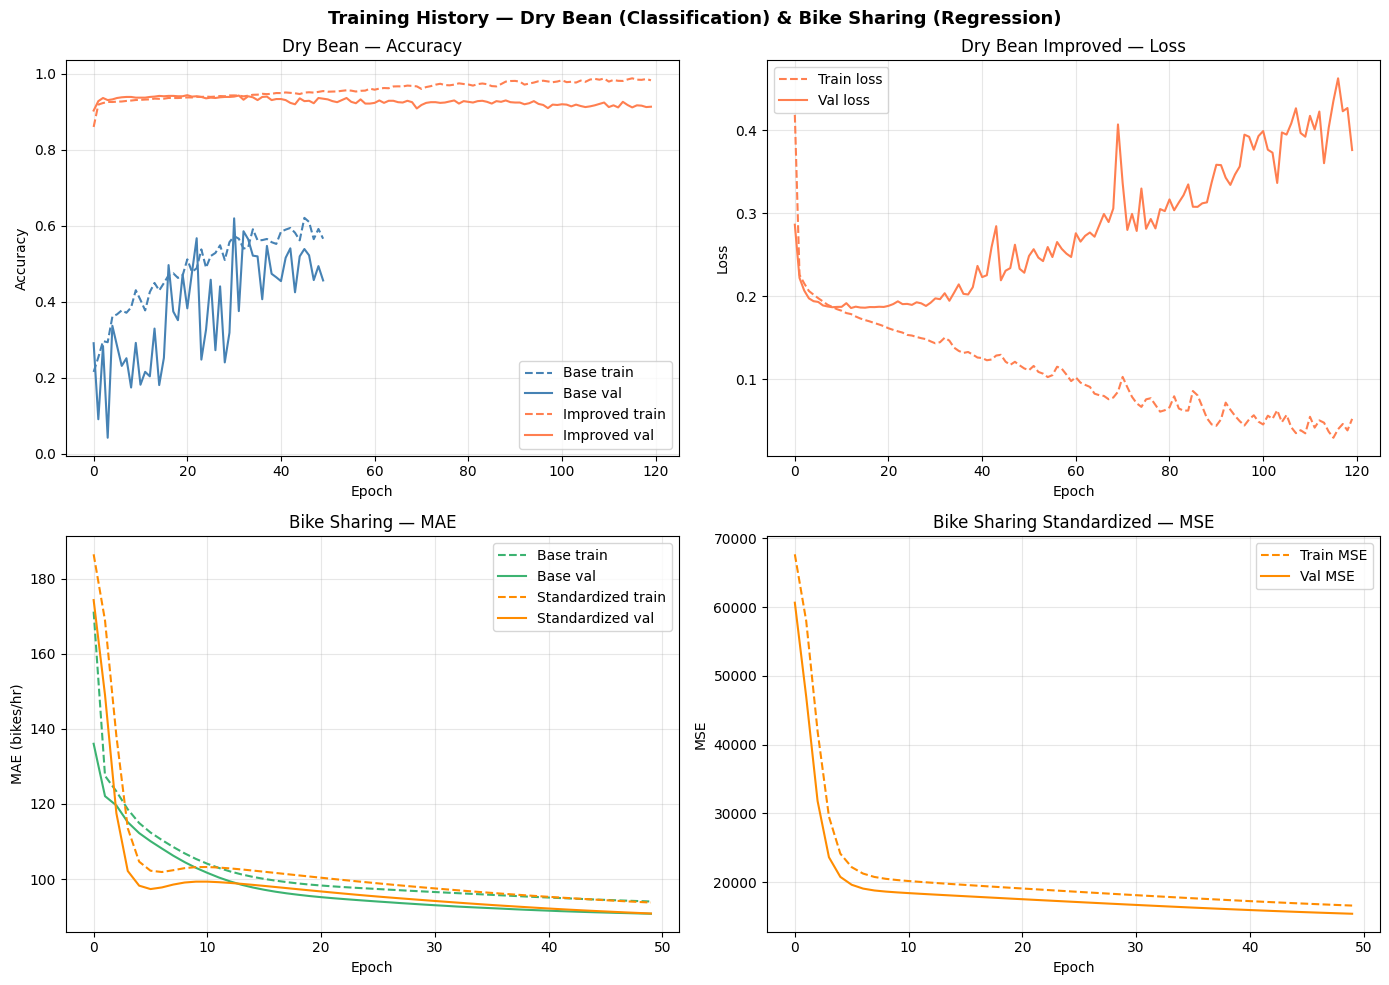

Saved: training_history.png


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History — Dry Bean (Classification) & Bike Sharing (Regression)',
             fontsize=13, fontweight='bold')

# Dry Bean: Accuracy — Base vs Improved
ax = axes[0, 0]
ax.plot(db_base_history.history['accuracy'],
        color='steelblue', linestyle='--', label='Base train')
ax.plot(db_base_history.history['val_accuracy'],
        color='steelblue', label='Base val')
ax.plot(db_improved_history.history['accuracy'],
        color='coral', linestyle='--', label='Improved train')
ax.plot(db_improved_history.history['val_accuracy'],
        color='coral', label='Improved val')
ax.set_title('Dry Bean — Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

# Dry Bean: Loss — Improved model
ax = axes[0, 1]
ax.plot(db_improved_history.history['loss'],
        color='coral', linestyle='--', label='Train loss')
ax.plot(db_improved_history.history['val_loss'],
        color='coral', label='Val loss')
ax.set_title('Dry Bean Improved — Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# Bike Sharing: MAE — Base vs Standardized
ax = axes[1, 0]
ax.plot(bk_base_history.history['mae'],
        color='mediumseagreen', linestyle='--', label='Base train')
ax.plot(bk_base_history.history['val_mae'],
        color='mediumseagreen', label='Base val')
ax.plot(bk_standard_history.history['mae'],
        color='darkorange', linestyle='--', label='Standardized train')
ax.plot(bk_standard_history.history['val_mae'],
        color='darkorange', label='Standardized val')
ax.set_title('Bike Sharing — MAE'); ax.set_xlabel('Epoch'); ax.set_ylabel('MAE (bikes/hr)')
ax.legend(); ax.grid(True, alpha=0.3)

# Bike Sharing: MSE — Standardized model
ax = axes[1, 1]
ax.plot(bk_standard_history.history['loss'],
        color='darkorange', linestyle='--', label='Train MSE')
ax.plot(bk_standard_history.history['val_loss'],
        color='darkorange', label='Val MSE')
ax.set_title('Bike Sharing Standardized — MSE'); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: training_history.png')

8. Show the application of Dropout Regularization


In [38]:
EPOCHS = 80
BATCH  = 64
N_IN   = X_db_train_sc.shape[1]

In [39]:
# Full Dropout — visible + hidden layers
db_drop_full = Sequential([
    Dropout(0.2, input_shape=(N_IN,)),    # visible layer dropout
    Dense(256, activation='relu'),
    Dropout(0.3),                          # hidden dropout
    Dense(128, activation='relu'),
    Dropout(0.3),                          # hidden dropout
    Dense(64,  activation='relu'),
    Dense(7,   activation='softmax')
], name='db_dropout_full')
db_drop_full.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])
h8 = db_drop_full.fit(X_db_train_sc, y_db_train, epochs=EPOCHS, batch_size=BATCH,
                      validation_split=0.1, verbose=1)
_, acc8 = db_drop_full.evaluate(X_db_test_sc, y_db_test, verbose=1)
print(f'  Improved model (baseline)            : {acc_db_imp:.4f}')
print(f'  Item  8 — Full Dropout               : {acc8:.4f}')

Epoch 1/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7554 - loss: 0.6810 - val_accuracy: 0.9238 - val_loss: 0.2592
Epoch 2/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8560 - loss: 0.3964 - val_accuracy: 0.9311 - val_loss: 0.2222
Epoch 3/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8694 - loss: 0.3575 - val_accuracy: 0.9311 - val_loss: 0.2097
Epoch 4/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8772 - loss: 0.3367 - val_accuracy: 0.9320 - val_loss: 0.2117
Epoch 5/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8871 - loss: 0.3209 - val_accuracy: 0.9385 - val_loss: 0.2069
Epoch 6/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8898 - loss: 0.3075 - val_accuracy: 0.9265 - val_loss: 0.2152
Epoch 7/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8932 - loss: 0.2962 - val_accuracy: 0.9256 - val_loss: 0.2115
Epoch 8/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8921 - loss: 0.2895 - val_accuracy: 0

9. Show the application of Dropout on the visible layer


In [40]:
# Dropout on visible (input) layer only
db_drop_vis = Sequential([
    Dropout(0.2, input_shape=(N_IN,)),    # visible only
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(7,   activation='softmax')
], name='db_dropout_visible')
db_drop_vis.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
h9 = db_drop_vis.fit(X_db_train_sc, y_db_train, epochs=EPOCHS, batch_size=BATCH,
                     validation_split=0.1, verbose=1)
_, acc9 = db_drop_vis.evaluate(X_db_test_sc, y_db_test, verbose=1)

print(f'  Improved model (baseline)            : {acc_db_imp:.4f}')
print(f'  Item  9 — Visible Layer Dropout      : {acc9:.4f}')

Epoch 1/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8113 - loss: 0.5484 - val_accuracy: 0.9219 - val_loss: 0.2551
Epoch 2/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8815 - loss: 0.3251 - val_accuracy: 0.9320 - val_loss: 0.2220
Epoch 3/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8862 - loss: 0.2970 - val_accuracy: 0.9357 - val_loss: 0.2093
Epoch 4/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8977 - loss: 0.2795 - val_accuracy: 0.9229 - val_loss: 0.2153
Epoch 5/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8998 - loss: 0.2725 - val_accuracy: 0.9219 - val_loss: 0.2145
Epoch 6/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9028 - loss: 0.2599 - val_accuracy: 0.9137 - val_loss: 0.2237
Epoch 7/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9047 - loss: 0.2531 - val_accuracy: 0.9164 - val_loss: 0.2226
Epoch 8/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9071 - loss: 0.2462 - val_accuracy: 0

10. Show the application of Dropout on the hidden layer


In [41]:
# Dropout on hidden layers only
db_drop_hid = Sequential([
    Dense(256, activation='relu', input_shape=(N_IN,)),
    Dropout(0.3),                          # hidden only
    Dense(128, activation='relu'),
    Dropout(0.3),                          # hidden only
    Dense(64,  activation='relu'),
    Dense(7,   activation='softmax')
], name='db_dropout_hidden')
db_drop_hid.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
h10 = db_drop_hid.fit(X_db_train_sc, y_db_train, epochs=EPOCHS, batch_size=BATCH,
                      validation_split=0.1, verbose=1)
_, acc10 = db_drop_hid.evaluate(X_db_test_sc, y_db_test, verbose=1)
print(f'  Improved model (baseline)            : {acc_db_imp:.4f}')
print(f'  Item 10 — Hidden Layers Dropout      : {acc10:.4f}')

Epoch 1/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8147 - loss: 0.5285 - val_accuracy: 0.9265 - val_loss: 0.2173
Epoch 2/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9071 - loss: 0.2656 - val_accuracy: 0.9302 - val_loss: 0.1968
Epoch 3/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9148 - loss: 0.2401 - val_accuracy: 0.9330 - val_loss: 0.1937
Epoch 4/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9159 - loss: 0.2352 - val_accuracy: 0.9339 - val_loss: 0.1956
Epoch 5/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9209 - loss: 0.2244 - val_accuracy: 0.9330 - val_loss: 0.1960
Epoch 6/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9202 - loss: 0.2205 - val_accuracy: 0.9376 - val_loss: 0.1939
Epoch 7/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9205 - loss: 0.2196 - val_accuracy: 0.9311 - val_loss: 0.1932
Epoch 8/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9245 - loss: 0.2114 - val_accuracy: 0

11. Show the application of a time-based learning rate schedule


In [42]:
# Time-Based Learning Rate Schedule
# lr_t = lr_0 / (1 + decay * t)  built into SGD's decay parameter
lr0   = 0.01
decay = lr0 / EPOCHS

db_time_lr = Sequential([
    Dense(256, activation='relu', input_shape=(N_IN,)),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(7,   activation='softmax')
], name='db_time_lr')
db_time_lr.compile(
    optimizer=SGD(learning_rate=lr0, momentum=0.9, decay=decay, nesterov=False),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
h11 = db_time_lr.fit(X_db_train_sc, y_db_train, epochs=EPOCHS, batch_size=BATCH,
                     validation_split=0.1, verbose=1)
_, acc11 = db_time_lr.evaluate(X_db_test_sc, y_db_test, verbose=1)
print(f'  Improved model (baseline)            : {acc_db_imp:.4f}')
print(f'  Item 11 — Time-Based LR Schedule     : {acc11:.4f}')

Epoch 1/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8218 - loss: 0.5974 - val_accuracy: 0.9201 - val_loss: 0.2586
Epoch 2/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9165 - loss: 0.2346 - val_accuracy: 0.9376 - val_loss: 0.2139
Epoch 3/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9213 - loss: 0.2143 - val_accuracy: 0.9385 - val_loss: 0.2002
Epoch 4/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9247 - loss: 0.2051 - val_accuracy: 0.9385 - val_loss: 0.1950
Epoch 5/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9261 - loss: 0.1995 - val_accuracy: 0.9357 - val_loss: 0.1929
Epoch 6/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9284 - loss: 0.1955 - val_accuracy: 0.9339 - val_loss: 0.1915
Epoch 7/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9291 - loss: 0.1925 - val_accuracy: 0.9348 - val_loss: 0.1908
Epoch 8/80
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9295 - loss: 0.1900 - val_accuracy: 0

12. Show the application of a drop-based learning rate schedule

In [43]:
# Item 12: Drop-Based (Step Decay) LR Schedule
# lr = lr0 * drop ^ floor((1 + epoch) / drop_every)
lr0_drop   = 0.1
drop_rate  = 0.5    # halve LR each step
drop_every = 20     # step every 20 epochs

def step_decay(epoch):
    return lr0_drop * math.pow(drop_rate, math.floor((1 + epoch) / drop_every))

db_drop_lr = Sequential([
    Dense(256, activation='relu', input_shape=(N_IN,)),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(7,   activation='softmax')
], name='db_drop_lr')
db_drop_lr.compile(
    optimizer=SGD(learning_rate=lr0_drop, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
h12 = db_drop_lr.fit(X_db_train_sc, y_db_train, epochs=EPOCHS, batch_size=BATCH,
                     validation_split=0.1,
                     callbacks=[LearningRateScheduler(step_decay, verbose=1)],
                     verbose=0)
_, acc12 = db_drop_lr.evaluate(X_db_test_sc, y_db_test, verbose=1)
print(f'  Improved model (baseline)            : {acc_db_imp:.4f}')
print(f'  Item 12 — Drop-Based LR Schedule     : {acc12:.4f}')


Epoch 1: LearningRateScheduler setting learning rate to 0.1.

Epoch 2: LearningRateScheduler setting learning rate to 0.1.

Epoch 3: LearningRateScheduler setting learning rate to 0.1.

Epoch 4: LearningRateScheduler setting learning rate to 0.1.

Epoch 5: LearningRateScheduler setting learning rate to 0.1.

Epoch 6: LearningRateScheduler setting learning rate to 0.1.

Epoch 7: LearningRateScheduler setting learning rate to 0.1.

Epoch 8: LearningRateScheduler setting learning rate to 0.1.

Epoch 9: LearningRateScheduler setting learning rate to 0.1.

Epoch 10: LearningRateScheduler setting learning rate to 0.1.

Epoch 11: LearningRateScheduler setting learning rate to 0.1.

Epoch 12: LearningRateScheduler setting learning rate to 0.1.

Epoch 13: LearningRateScheduler setting learning rate to 0.1.

Epoch 14: LearningRateScheduler setting learning rate to 0.1.

Epoch 15: LearningRateScheduler setting learning rate to 0.1.

Epoch 16: LearningRateScheduler setting learning rate to 0.1.



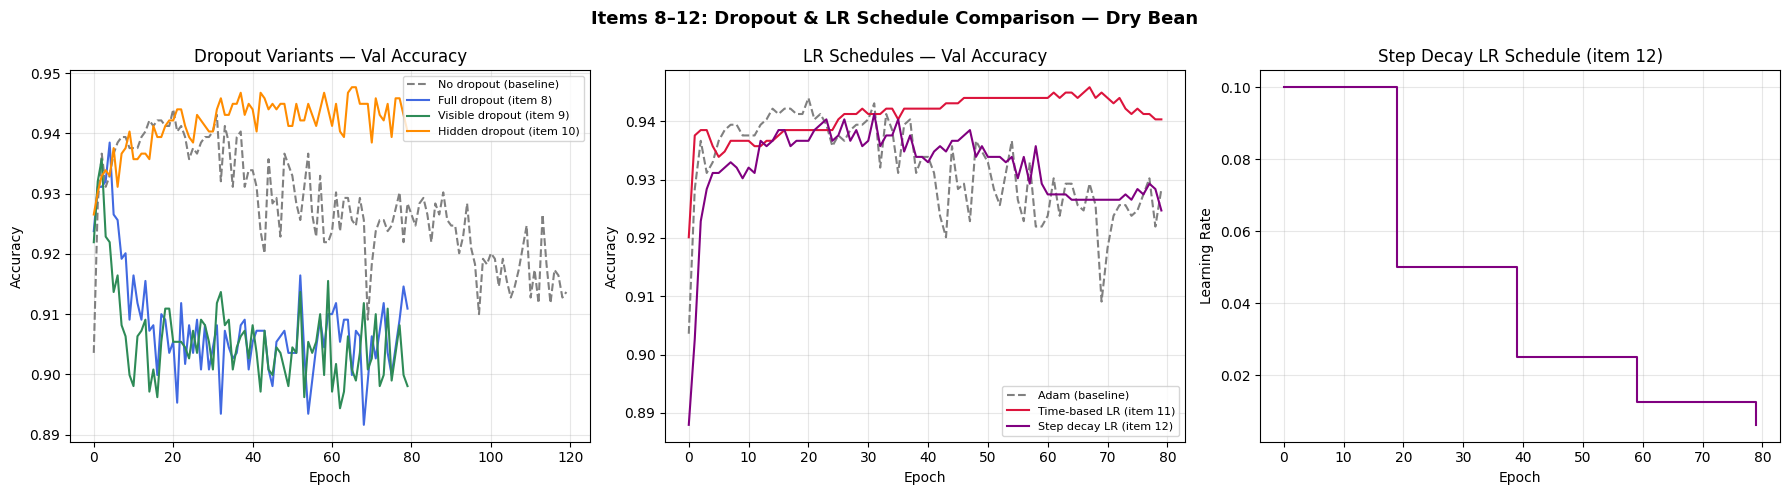

Saved: dropout_lr_comparison.png


In [44]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Items 8–12: Dropout & LR Schedule Comparison — Dry Bean',
             fontsize=13, fontweight='bold')

baseline = db_improved_history.history['val_accuracy']

# Plot 1: Dropout variants
ax = axes[0]
ax.plot(baseline, color='gray', linestyle='--', label='No dropout (baseline)')
ax.plot(h8.history['val_accuracy'],  color='royalblue',  label='Full dropout (item 8)')
ax.plot(h9.history['val_accuracy'],  color='seagreen',   label='Visible dropout (item 9)')
ax.plot(h10.history['val_accuracy'], color='darkorange',  label='Hidden dropout (item 10)')
ax.set_title('Dropout Variants — Val Accuracy')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Plot 2: LR schedule variants
ax = axes[1]
ax.plot(baseline[:EPOCHS], color='gray', linestyle='--', label='Adam (baseline)')
ax.plot(h11.history['val_accuracy'], color='crimson', label='Time-based LR (item 11)')
ax.plot(h12.history['val_accuracy'], color='purple',  label='Step decay LR (item 12)')
ax.set_title('LR Schedules — Val Accuracy')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Plot 3: Step decay schedule shape
ax = axes[2]
ep = range(EPOCHS)
ax.step(ep, [step_decay(e) for e in ep], color='purple', where='post')
ax.set_title('Step Decay LR Schedule (item 12)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dropout_lr_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: dropout_lr_comparison.png')

Implementing dropout at the hidden layers only yielded the best results.  Full dropout and visible dropout both resulted to worse outcomes compared to the baseline model.

Additionally, both time-based and step decay LR resulted to the model performing better compared to just using Adam. Time-based LR yielded the best results.

The step decay schedule shows how the model adjusts the learning rate as the number of epochs. This yielded a better model outcome compared to the baseline.

# Conclusion

## Anduque

I was able to learn how to save a model in various file formats through this exercise. Additionally, we were able to load them again for use. Furthermore, I learned another method for storing models, which is by saving checkpoints. I was also able to experiment with various regularization strategies and determine which is most effective for the task at hand.

## Pascual

In this activity, I was able to learn how to save a model in different file formats. I was also able to load them back for usage. I was able to realize how file management is important when saving and loading models, as it can get quite messy after training. Saving checkpoints also seems to be an interesting technique for saving models. Additionally, I was able to test out different regularization techniques and assess which works best for the given task.